---
date: "2026-07-18"
date-modified: last-modified
format:
  html:
    toc: true
---

<!-- CELL BREAK -->

# Multinomial Distribution

The **multinomial distribution** is a discrete multivariate probability distribution. It serves as the higher-dimensional generalization of the [binomial distribution](bernoulli-and-binomial-distributions.ipynb). While the binomial distribution models the number of successes in $n$ independent trials with two possible outcomes, the multinomial distribution models the counts of outcomes when there are $k$ mutually exclusive categories.

## 1\. Story and Definition

Suppose we have $n$ independent objects (or trials) and we are sorting them into $k$ distinct categories. 

The parameters of the distribution are:

* The number of trials: $n$
* The probability vector: $\vec{p} = (p_1, p_2, \dots, p_k)$

The probabilities must satisfy:

* $p_j \ge 0$ for all $j$
* $\sum_{j=1}^k p_j = 1$

If we define the random vector $\vec{X} = (X_1, X_2, \dots, X_k)$, where $X_j$ represents the number of objects that fall into category $j$, then $\vec{X}$ follows a multinomial distribution:
$$\vec{X} \sim \text{Mult}_k(n, \vec{p})$$

::: {.callout-note}
## Intuition: The Category Constraint
Because the $n$ objects must be partitioned exactly into the $k$ categories, the sum of the random variables is deterministic: $\sum_{j=1}^k X_j = n$. Therefore, even though $\vec{X}$ has $k$ components, it only has $k-1$ degrees of freedom.
:::

<!-- CELL BREAK -->

## 2\. Joint Probability Mass Function

The joint [probability mass function](probability-mass-function.ipynb) (PMF) gives the probability of observing a specific configuration of counts $(x_1, x_2, \dots, x_k)$. 

$$P(X_1 = x_1, X_2 = x_2, \dots, X_k = x_k) = \frac{n!}{x_1! x_2! \dots x_k!} p_1^{x_1} p_2^{x_2} \dots p_k^{x_k}$$

This is valid for any set of non-negative integers $x_1, \dots, x_k$ such that $x_1 + x_2 + \dots + x_k = n$.

<!-- CELL BREAK -->

## 3\. Marginal Distributions

If we look at just one category $j$ and ignore the rest, we are essentially classifying every object as either "belongs to category $j$" (with probability $p_j$) or "does not belong to category $j$" (with probability $1-p_j$). 

Therefore, the marginal distribution of any single component $X_j$ is simply a binomial distribution:
$$X_j \sim \text{Bin}(n, p_j)$$

<!-- CELL BREAK -->

## 4\. Lumping Property

If we group or "lump" categories together, the resulting vector is still multinomially distributed. The new probabilities and counts are simply the sums of the lumped components.

**Proposition (Lumping Categories):**
Let $\vec{X} = (X_1, X_2, \dots, X_{10}) \sim \text{Mult}_{10}(n, (p_1, \dots, p_{10}))$. 
If we define a new random vector by combining categories 3 through 10:
$$\vec{Y} = (X_1, X_2, X_3 + \dots + X_{10})$$
Then $\vec{Y}$ follows a 3-category multinomial distribution:
$$\vec{Y} \sim \text{Mult}_3\Big(n, (p_1, p_2, p_3 + \dots + p_{10})\Big)$$

<!-- CELL BREAK -->

## 5\. Conditional Distribution

What happens if we reveal the count for one of the categories? Suppose we are given that $X_1 = x_1$. 

The remaining $n - x_1$ objects must now be distributed among the remaining $k-1$ categories $(X_2, \dots, X_k)$. Since category 1 is no longer an option, we must renormalize the probabilities of the remaining categories so that they sum to 1.

Given $X_1 = x_1$, the conditional distribution of the remaining variables is:
$$(X_2, \dots, X_k) \sim \text{Mult}_{k-1}(n - x_1, (p_2', \dots, p_k'))$$

Where the new scaled probabilities are:
$$p_j' = \frac{p_j}{1 - p_1} = \frac{p_j}{p_2 + \dots + p_k} \quad \text{for } j \in \{2, \dots, k\}$$

::: {.callout-note}
## Intuition: Renormalizing Probabilities
If we know exactly how many items landed in category 1, the "experiment" for the remaining items is effectively restricted to categories $2$ through $k$. The relative likelihood of falling into category 2 versus category 3 remains unchanged, but their absolute probabilities must be scaled up by $\frac{1}{1-p_1}$ to ensure they form a valid probability space.
:::

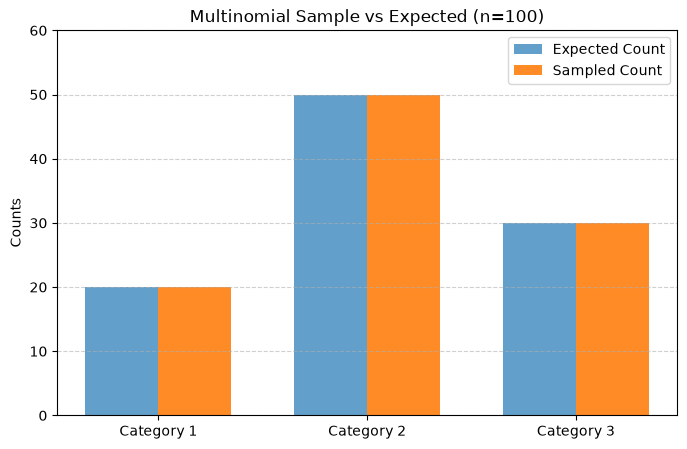

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a multinomial distribution
n_trials = 100
probabilities = [0.2, 0.5, 0.3]
categories = ['Category 1', 'Category 2', 'Category 3']

# Draw one sample
sample = np.random.multinomial(n_trials, probabilities)

# Plot the expected vs actual counts for a single realization
expected = [n_trials * p for p in probabilities]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, expected, width, label='Expected Count', alpha=0.7)
rects2 = ax.bar(x + width/2, sample, width, label='Sampled Count', alpha=0.9)

ax.set_ylabel('Counts')
ax.set_title(f'Multinomial Sample vs Expected (n={n_trials})')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, max(expected + list(sample)) * 1.2)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()